### 1.Environment Setup

In [2]:
!pip install transformers datasets sentence-transformers faiss-cpu evaluate pandas numpy matplotlib scikit-learn

In [3]:
!pip install datasets

In [4]:
import sys
!{sys.executable} -m pip install datasets


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/bin/python -m pip install --upgrade pip


### 2.Dataset Loading

 I chose the PubMedQA dataset, which is ideal for biomedical QA.

In [5]:
from datasets import load_dataset

dataset = load_dataset("pubmed_qa", "pqa_labeled")

dataset

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})

import sys
print(sys.executable)

- JupyterLab environment setup completed
- Python virtual environment confirmed
- Required libraries installed
- PubMedQA dataset successfully loaded
- Dataset structure identified

Next step:
Dataset exploration and analysis.

### 3.Inspecting One Data Sample

In [7]:
dataset["train"][0]

{'pubid': 21645374,
 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?',
 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.',
   'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), ce

### 4.Understanding Example Data:
Input:
Question + Context

Output:
yes / no / maybe

Example:
Question:
Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?

Context:
(medical research text)

Prediction:
yes


### Dataset Structure

Each sample in the PubMedQA dataset contains:

- pubid: PubMed article identifier
- question: biomedical research question
- context: text from biomedical literature
- long_answer: explanation derived from the paper
- final_decision: classification label (yes / no / maybe)

The task is to predict the correct decision using the question and context.

### 5.Checking Dataset Distribution

In [8]:
from collections import Counter

answers = [item["final_decision"] for item in dataset["train"]]

Counter(answers)

Counter({'yes': 552, 'no': 338, 'maybe': 110})

The PubMedQA dataset contains three answer classes: **yes**, **no**, and **maybe**.  
The distribution of these classes is shown in the table below.

### 6.Interpreting Dataset Statistics

| Label | Count | Percentage |
|------|------|-----------|
| yes | 552 | 55.2% |
| no | 338 | 33.8% |
| maybe | 110 | 11.0% |

### 7.Visualization

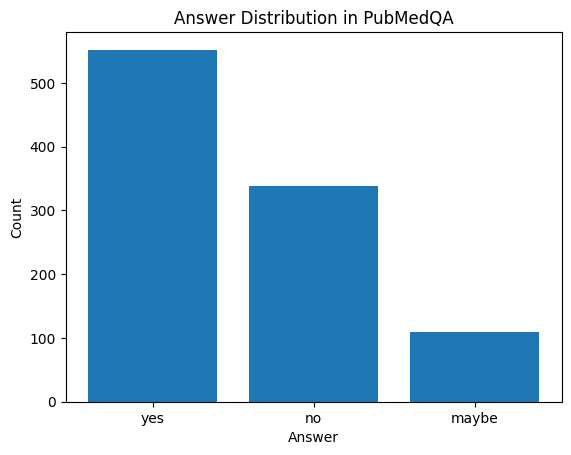

In [9]:
import matplotlib.pyplot as plt

labels = ['yes', 'no', 'maybe']
counts = [552, 338, 110]

plt.bar(labels, counts)
plt.title("Answer Distribution in PubMedQA")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

### Dataset Analysis
The PubMedQA dataset contains biomedical research questions...